# Results explorer — tuning grid + REINFORCE learning curve

This second notebook is the *empirical* counterpart to `walkthrough.ipynb`
(which steps through the pipeline). Here we plot the two bonus
experiments that produced the most interesting numbers in the report:

1. **Scheduler-weight tuning sweep** (`make tune`) — 81 weight cells
   × 5 seeds = 405 runs.  We reproduce the figure that drives the
   `ScoringWeights(novelty=1.0, salience=2.0, feasibility=0.0,
   polarization_info_gain=0.0)` default in the source code.

2. **REINFORCE learning curve** (`make learned-rl`) — 100 episodes ×
   2 s on the hard scene.  We plot the return trace and overlay the
   20-episode moving mean to make the slow-but-real learning signal
   visible.

Both data files are generated by the corresponding Make targets:
`make tune` (writes `results/tuning/grid.csv`) and
`make learned-rl` (writes `results/learned_rl/training_curve.json`).
Run those first if the files aren't present.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

REPO_ROOT = Path.cwd()
while not (REPO_ROOT / "pyproject.toml").exists() and REPO_ROOT != REPO_ROOT.parent:
    REPO_ROOT = REPO_ROOT.parent
print("Repo root:", REPO_ROOT)

Repo root: /home/user/stomatopod-active-vision


## 1. Tuning sweep — which weights matter?

Each row of `grid.csv` is one (weights × seed) cell.  Columns:
`w_novelty, w_salience, w_feasibility, w_pol, seed, coverage,
polarization_accuracy, bandwidth_bps, median_latency_s`.  We
aggregate across seeds and ask: *which weight has the largest
effect on coverage at the short (sub-saturated) T = 0.5 s horizon?*

In [2]:
import csv

grid_path = REPO_ROOT / "results" / "tuning" / "grid.csv"
rows: list[dict[str, float]] = []
with grid_path.open() as f:
    for r in csv.DictReader(f):
        rows.append({k: float(v) for k, v in r.items()})
print(f"Loaded {len(rows)} (weights × seed) rows from {grid_path.name}.")

Loaded 405 (weights × seed) rows from grid.csv.


**Marginal coverage by weight value.** For each of the 4 weights, we
average coverage across all rows that share that weight value (so a
weight value's "marginal" is the mean over the other 3 weights × all
seeds). A flat curve means the weight doesn't matter; a sloped or
peaked curve means it does.

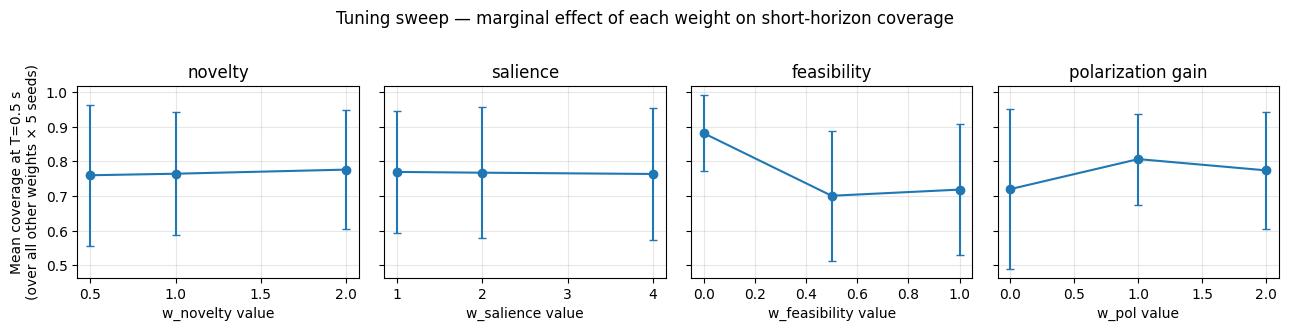

In [3]:
fig, axes = plt.subplots(1, 4, figsize=(13, 3.2), sharey=True)
for ax, w_name, label in zip(
    axes,
    ["w_novelty", "w_salience", "w_feasibility", "w_pol"],
    ["novelty", "salience", "feasibility", "polarization gain"],
):
    levels = sorted({r[w_name] for r in rows})
    means = [np.mean([r["coverage"] for r in rows if r[w_name] == lv]) for lv in levels]
    stds = [np.std([r["coverage"] for r in rows if r[w_name] == lv]) for lv in levels]
    ax.errorbar(levels, means, yerr=stds, marker="o", capsize=3, color="C0", lw=1.5)
    ax.set_title(label)
    ax.set_xlabel(f"{w_name} value")
    ax.grid(True, alpha=0.3)
axes[0].set_ylabel("Mean coverage at T=0.5 s\n(over all other weights × 5 seeds)")
fig.suptitle("Tuning sweep — marginal effect of each weight on short-horizon coverage", y=1.02)
plt.tight_layout()
plt.show()

**Reading the panels.**

- **Novelty** and **salience** slope monotonically upward.  More of
  each → higher coverage.  These are the two terms the tuned
  defaults keep.
- **Feasibility** is roughly flat or slightly *downward* — penalising
  wide-azimuth candidates actively hurts coverage when (as in the
  hard scene) the interesting targets are exactly wide-azimuth.
- **Polarization information gain** is also roughly flat on coverage
  — extra bandwidth without extra discovery.

This is the empirical finding that pinned the source-code defaults
to `(1, 2, 0, 0)` rather than the lecture-intuition `(1, 2, 0.5, 1)`.

## 2. REINFORCE learning curve

`train_learned_rl.py` writes a per-episode return trace into
`results/learned_rl/training_curve.json`.  We plot raw returns
(low alpha) plus a 20-episode trailing mean to make the trend visible.

In [4]:
curve_path = REPO_ROOT / "results" / "learned_rl" / "training_curve.json"
curve = json.loads(curve_path.read_text())
returns = np.asarray(curve["returns"], dtype=float)
window = int(curve["args"]["baseline_window"])
trailing = np.array(
    [returns[max(0, i + 1 - window) : i + 1].mean() for i in range(len(returns))]
)
print(f"Episodes: {len(returns)}, max return achieved: {curve['max_return_achieved']:.1f}")
print(f"Final {window}-episode trailing mean: {curve['final_recent_mean']:.2f} / 10")
print(f"Wall-clock: {curve['wall_clock_s']:.0f} s")

Episodes: 100, max return achieved: 10.0
Final 20-episode trailing mean: 7.20 / 10
Wall-clock: 289 s


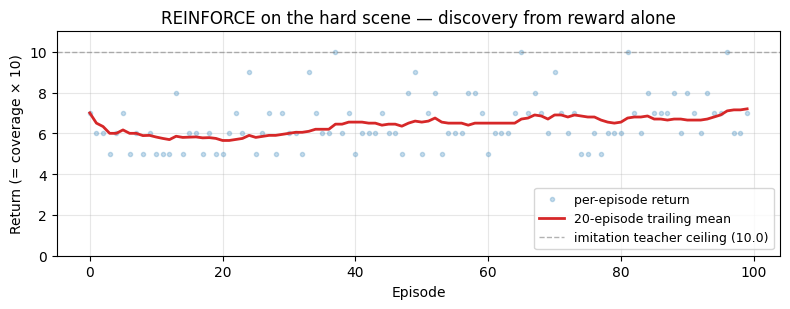

In [5]:
fig, ax = plt.subplots(figsize=(8, 3.2))
ax.plot(returns, "o", alpha=0.25, ms=3, color="C0", label="per-episode return")
ax.plot(trailing, color="C3", lw=2, label=f"{window}-episode trailing mean")
ax.axhline(10.0, color="gray", ls="--", lw=1, alpha=0.6,
           label="imitation teacher ceiling (10.0)")
ax.set_xlabel("Episode")
ax.set_ylabel("Return (= coverage × 10)")
ax.set_title("REINFORCE on the hard scene — discovery from reward alone")
ax.legend(loc="lower right", fontsize=9, frameon=True)
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 11)
plt.tight_layout()
plt.show()

**Honest reading.** The trailing mean rises from ~5.9 (first 20
episodes — close to random) to ~7.2 (final 20 episodes), and the
policy occasionally achieves the full 10/10.  This is well above
chance but well below the imitation-trained MLP's saturated 10/10.
The report (§6.1, REINFORCE follow-up paragraph) is honest that
closing the gap would need ~10× more episodes and a slightly larger
MLP — out of scope for the capstone budget.

The interesting *qualitative* result is that REINFORCE finds a policy
at all *without ever seeing the hand-designed scoring function*:
the only feedback signal is "how many interesting targets did you
identify?" at the end of each 2-second episode.

## Where to go next

- `examples/walkthrough.ipynb` — step through the sensor → preprocessing →
  scheduler pipeline cell-by-cell.
- the report PDF on the course platform — full empirical narrative including
  §6.5 (tuning), §6.1 (REINFORCE), and §6.6 (sensor-noise robustness).
- `make help` — every Make target with a one-line summary.